# **Análise exploratória de dados** - Squad 11  
# <div align="center">**Hyozan**</div>



 - Conjunto de dados: Diabetes prediction dataset

 - Cientistas de dados:
      - Airan Rejane Conceição Dos Santos
      - Isabeli Romano Rodrigues
      - João Volney Grangeiro Dos Santos
      - Juvenal Da Costa Lavres Da Conceição
      - Marina Souza Cavalcante De Carvalho  
      -  Natalia Ligabo Dos Santos

#### **Distribuição das tarefas**

##### Descrição dos dados:

* Dicionário dos dados - *Marina Carvalho*
* Análise univariada - *João Volney*
* Análise bivariada - *Airan Rejane*
* Análise multivariada - *Natalia Ligabo*
* Sumário de Insights e hipóteses - *Juvenal Lavres*

In [ ]:
# @title Importação das bibliotecas

# Tools module
import itertools

# Core data manipulation
import pandas as pd
import numpy as np

# Statistical analysis
from scipy import stats as st

# Visualization
from matplotlib import pyplot as plt
import seaborn as sns

# Set display markdown options
from IPython.display import Markdown

# Matriz de Confusão
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [ ]:
#@title Leitura do conjunto de dados
df=pd.read_csv("https://raw.githubusercontent.com/atlantico-academy/datasets/refs/heads/main/diabetes.csv")

---
## **Informações Básicas**

---


In [ ]:
# @title Informações básicas e shape

print(f'Dataset shape: {df.shape}')
print(f'Linhas: {df.shape[0]}, Colunas: {df.shape[1]}.')

Dataset shape: (100000, 9)
Linhas: 100000, Colunas: 9.


In [ ]:
display(Markdown("### Data types"))

df.dtypes

### Data types

,0
gender,object
age,float64
hypertension,int64
heart_disease,int64
smoking_history,object
bmi,float64
HbA1c_level,float64
blood_glucose_level,int64
diabetes,int64


In [ ]:
# @title Informações iniciais
display(Markdown("### Primeiras Linhas"))
df.head()

### Primeiras Linhas

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [ ]:
display(Markdown("### Ultimas Linhas"))
df.tail()

### Ultimas Linhas

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0
99999,Female,57.0,0,0,current,22.43,6.6,90,0


In [ ]:
display(Markdown("### Amostra Aleatória de 5 linhas"))

df.sample(5)

### Amostra Aleatória de 5 linhas

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
77997,Male,51.0,1,0,No Info,27.32,5.8,130,0
4507,Female,58.0,0,0,No Info,19.08,6.5,140,0
86522,Female,6.0,0,0,No Info,27.32,4.5,80,0
11959,Female,2.0,0,0,No Info,17.48,6.6,145,0
27966,Male,64.0,1,0,No Info,38.30,5.7,155,1


In [ ]:
display(Markdown("### Informações sobre o DataFrame"))
df.info()

### Informações sobre o DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [ ]:
display(Markdown("### Quantidade de Valores únicos"))
df.nunique()

### Quantidade de Valores únicos

,0
gender,3
age,102
hypertension,2
heart_disease,2
smoking_history,6
bmi,4247
HbA1c_level,18
blood_glucose_level,18
diabetes,2


In [ ]:
valores_unicos = df['gender'].unique()
print(valores_unicos)

['Female' 'Male' 'Other']


In [ ]:
valores_unicos = df['smoking_history'].unique()
print(valores_unicos)

['never' 'No Info' 'current' 'former' 'ever' 'not current']


In [ ]:
display(Markdown("### Quantidade de Linhas e Colunas"))
df.shape

### Quantidade de Linhas e Colunas

(100000, 9)

In [ ]:
#@title Dados Faltantes
display(Markdown("### Quantidade de Valores Nulos"))
df.isnull().sum()

### Quantidade de Valores Nulos

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0




Não Existem Dados Faltantes



---

# **Descrição dos Dados**

---

In [ ]:
#@title Dicionário de dados
df_dict = pd.DataFrame([
    {
        "variavel": "gender",
        "descricao": "Genero do participante (Male/Female/Other).",
        "tipo": "qualitativa",
        "subtipo": "nominal",
    },
    {
        "variavel": "age",
        "descricao": "Idade do participante.",
        "tipo": "quantitativa",
        "subtipo": "continua",
    },
    {
        "variavel": "hypertension",
        "descricao": "Se o participante possui Hipertenssão Arterial Sistemica (1/0).",
        "tipo": "qualitativa",
        "subtipo": "nominal",
    },
    {
        "variavel": "heart_disease",
        "descricao": "Se o participante possui alguma doença cardiaca(1/0)",
        "tipo": "qualitativa",
        "subtipo": "nominal",
    },
    {
        "variavel": "smoking_history",
        "descricao": "Categorias: se o participante fuma, já fumou ou nunca fumou. As possiveis respostas são ('never' 'No Info' 'current' 'former' 'ever' 'not current')", #por causa da ambiguidade da categoria no info a variavel sera tratada como nominal
        "tipo": "qualitativa",
        "subtipo": "nominal",
    },
    {
        "variavel": "bmi",
        "descricao": "Informa o IMC.",
        "tipo": "quantitativa",
        "subtipo": "contínua",
    },
    {
        "variavel": "HbA1c_level",
        "descricao": "Informa o nivel da hemoglobina glicada.", # com esta medida conseguimos a media diaria da glicose no soro pelos ultimos 3 meses, exame usado para diagnostico e controle de tratamento
        "tipo": "quantitativa",
        "subtipo": "contínua",
    },
    {
        "variavel": "blood_glucose_level",
        "descricao": "Informa o nivel da glicose no sangue.", # este  mostra a medida da glicose da hora da coleta do exame facilmente alterado pela ingestao de comida ou estresse
        "tipo": "quantitativa",
        "subtipo": "contínua",
    },
    {
        "variavel": "diabetes",
        "descricao": "Informa se o paciente possui ou nao diabetes (1/0).",
        "tipo": "qualitativa",
        "subtipo": "nominal",
    }
])
with pd.option_context('display.max_colwidth', None):
    display(df_dict)

,variavel,descricao,tipo,subtipo
0,gender,Genero do participante (Male/Female/Other).,qualitativa,nominal
1,age,Idade do participante.,quantitativa,continua
2,hypertension,Se o participante possui Hipertenssão Arterial Sistemica (1/0).,qualitativa,nominal
3,heart_disease,Se o participante possui alguma doença cardiaca(1/0),qualitativa,nominal
4,smoking_history,"Categorias: se o participante fuma, já fumou ou nunca fumou. As possiveis respostas são ('never' 'No Info' 'current' 'former' 'ever' 'not current')",qualitativa,nominal
5,bmi,Informa o IMC.,quantitativa,contínua
6,HbA1c_level,Informa o nivel da hemoglobina glicada.,quantitativa,contínua
7,blood_glucose_level,Informa o nivel da glicose no sangue.,quantitativa,contínua
8,diabetes,Informa se o paciente possui ou nao diabetes (1/0).,qualitativa,nominal


---

 # **Análise Univariada**

 ---


In [ ]:
#@title Resumo Estatístico
display(Markdown("### Variaveis quantitativas"))
print(df.describe())

display(Markdown("### Variaveis qualitativas"))
print(df.describe(include = "object"))

### Variaveis quantitativas

                 age  hypertension  heart_disease            bmi  \
count  100000.000000  100000.00000  100000.000000  100000.000000   
mean       41.885856       0.07485       0.039420      27.320767   
std        22.516840       0.26315       0.194593       6.636783   
min         0.080000       0.00000       0.000000      10.010000   
25%        24.000000       0.00000       0.000000      23.630000   
50%        43.000000       0.00000       0.000000      27.320000   
75%        60.000000       0.00000       0.000000      29.580000   
max        80.000000       1.00000       1.000000      95.690000   

         HbA1c_level  blood_glucose_level       diabetes  
count  100000.000000        100000.000000  100000.000000  
mean        5.527507           138.058060       0.085000  
std         1.070672            40.708136       0.278883  
min         3.500000            80.000000       0.000000  
25%         4.800000           100.000000       0.000000  
50%         5.800000           14

### Variaveis qualitativas

        gender smoking_history
count   100000          100000
unique       3               6
top     Female         No Info
freq     58552           35816



---

- Podemos perceber com esta analise inicial que a maior parte dos participantes esta no grupo de saudaveis. apenas 8,5% da amostra tem diabetes.
- A media da HbA1c é de 5.52, o que da uma media da glicose nos ultimos tres meses de 111 mais ou menos, mas mais baixo que a media da glicose colhida que foi 138.
- Predominantemente a maior parte dos participantes nâo possuem Hipertenssão nem doenças cardiacas, apenas 7,4% têm hipertensão e 3,9% doenças cardíacas
- O IMC da metade dos participantes é de 27 que ja é classificado como sobre peso.
- E um ponto interessante é que o maior IMC é 95,69, o que distoa um pouco, ja que apartir de 40 ja é considerado obesidade grau III
- O dataset é bem equilibrado na questao de idades pelo fato da média ser 41.8 anos e a mediana (50%) ser 43 anos. Importante apontar que a idade minima ser 0,08 indica que a bebes no conjunto.


---

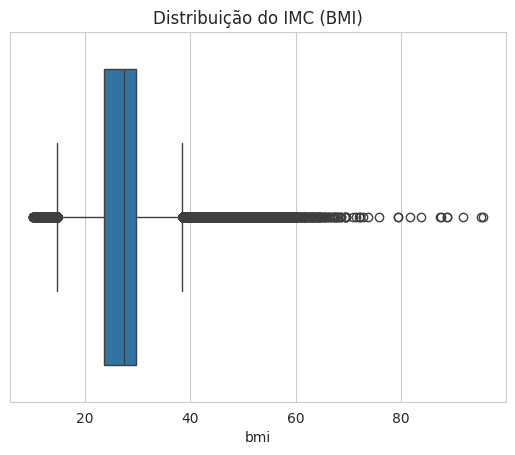

Limite Superior (IQR): 38.504999999999995
Quantidade de outliers: 5965


In [ ]:
#@title Analise e limpeza de dados (variavel BMI)
sns.boxplot(x=df['bmi'])
plt.title('Distribuição do IMC (BMI)')
plt.show()


Q1 = df['bmi'].quantile(0.25)
Q3 = df['bmi'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(f"Limite Superior (IQR): {limite_superior}")
outliers = df[df['bmi'] > limite_superior]
print(f"Quantidade de outliers: {len(outliers)}")



---
- Apesar da mediana ser 27.32 os pontos do boxspot continuam ate 95, isso mostra que temos alguns numeros discrepantes


---



In [ ]:
outliers_bmi = df[df['bmi'] > 70]

print(f"Total de registros com IMC > 70: {len(outliers_bmi)}")
print(outliers_bmi[['age', 'bmi', 'gender', 'diabetes']].describe())

babies_high_bmi = df[(df['age'] < 2) & (df['bmi'] > 40)]
print(f"Bebês com IMC > 40: {len(babies_high_bmi)}")

Total de registros com IMC > 70: 19
             age        bmi   diabetes
count  19.000000  19.000000  19.000000
mean   39.842105  81.121053   0.315789
std    15.987020   8.575702   0.477567
min     7.000000  70.960000   0.000000
25%    35.000000  72.585000   0.000000
50%    42.000000  79.480000   0.000000
75%    47.500000  88.210000   1.000000
max    80.000000  95.690000   1.000000
Bebês com IMC > 40: 0



---
 - Existem 19 registros com IMC de > 70:
   - entre eles uma criança de 7 anos.
   - 50% destes dados são de pessoas de ate 35 anos.
   - não existem no dataset bebes com IMC > 40


---



In [ ]:
outliers_bmi = df[df['bmi'] < 15]

print(f"Total de registros com IMC < 15: {len(outliers_bmi)}")
print(outliers_bmi[['age', 'bmi', 'gender', 'diabetes']].describe())

babies_high_bmi = df[(df['age'] < 2) & (df['bmi'] < 15)]
print(f"Bebês com IMC > 40: {len(babies_high_bmi)}")



Total de registros com IMC < 15: 1476
               age          bmi     diabetes
count  1476.000000  1476.000000  1476.000000
mean      6.619295    13.985793     0.008808
std      10.706139     0.965710     0.093466
min       0.080000    10.010000     0.000000
25%       1.720000    13.600000     0.000000
50%       5.000000    14.300000     0.000000
75%       8.000000    14.700000     0.000000
max      80.000000    14.990000     1.000000
Bebês com IMC > 40: 403


In [ ]:
Q1 = df['bmi'].quantile(0.25)
Q3 = df['bmi'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR


extremos = df[df['bmi'] > limite_superior]


print(extremos[['age', 'bmi', "heart_disease", "diabetes", "hypertension", "gender"]].sort_values(by='bmi', ascending=False).head(20))

        age    bmi  heart_disease  diabetes  hypertension  gender
87843   7.0  95.69              0         0             0    Male
76093  16.0  95.22              0         0             0    Male
69549  38.0  91.82              0         0             0    Male
96066  80.0  88.76              0         0             0    Male
4551   45.0  88.72              0         1             0  Female
90043  34.0  87.70              0         0             0  Female
22454  19.0  87.51              0         0             0    Male
24186  49.0  83.74              0         1             0    Male
71485  48.0  81.73              0         1             0  Female
20591  39.0  79.48              0         0             0  Female
58318  36.0  79.46              0         1             0  Female
54336  25.0  75.78              0         0             0  Female
20355  55.0  73.77              0         0             0  Female
28645  42.0  72.89              0         1             0  Female
21960  47.



---

- Analisando os dados extremos, podemos ver que o maior indice do IMC é de uma criança de 7 anos, e um adolecente de 16 anos o que é um pouco improvavel ja que o IMC não é uma medida estática para o publico pediatrico como no adulto, mas sim baseada em curvas de percentis da OMS. Um IMC de 95 está tão fora da curva que não seria apenas obesidade, mas um caso de repercussão médica internacional, o que reforça a tese de erro de digitação

  - Criança de 7 anos (IMC 95.69): Com uma altura média de 1,22m, essa criança teria que pesar 142,4 kg.

  - Jovem de 16 anos (IMC 95.22): Com uma altura média de 1,70m, ele(a) teria que pesar 275,2 kg.

- Em idades avançadas, um IMC levemente mais alto pode ser protetor, mas valores acima de 40 (como os 88 do dataset) são extremamente raros devido à fragilidade biológica natural dessa fase, e os processos como a sarcopenia (perda de massa muscular no idoso)

---



In [ ]:

extremos = df[df['bmi'] > 70]
analise_correlacao = extremos[['diabetes', 'heart_disease']].mean() * 100

print("Percentual de incidência nos casos de IMC extremo (> 70):")
print(f"Diabetes: {analise_correlacao['diabetes']:.2f}%")
print(f"Doenças Cardíacas: {analise_correlacao['heart_disease']:.2f}%")

normal = df[df['bmi'] <= 70]
analise_normal = normal[['diabetes', 'heart_disease']].mean() * 100

print("\nPercentual de incidência no restante do dataset (IMC <= 70):")
print(f"Diabetes: {analise_normal['diabetes']:.2f}%")
print(f"Doenças Cardíacas: {analise_normal['heart_disease']:.2f}%")

Percentual de incidência nos casos de IMC extremo (> 70):
Diabetes: 31.58%
Doenças Cardíacas: 0.00%

Percentual de incidência no restante do dataset (IMC <= 70):
Diabetes: 8.50%
Doenças Cardíacas: 3.94%


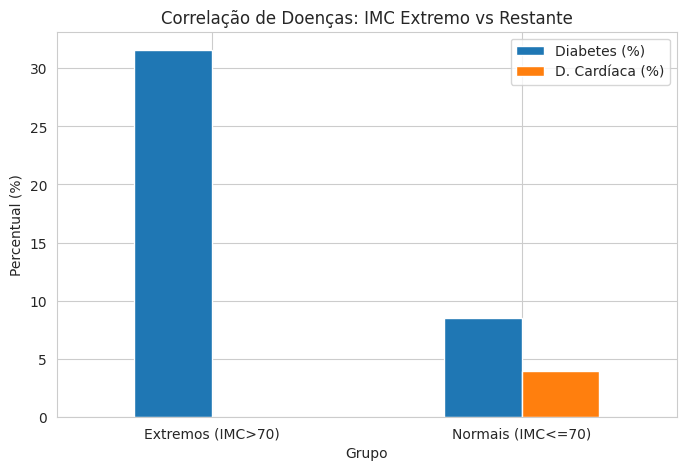

In [ ]:
comparativo = pd.DataFrame({
    'Grupo': ['Extremos (IMC>70)', 'Normais (IMC<=70)'],
    'Diabetes (%)': [analise_correlacao['diabetes'], analise_normal['diabetes']],
    'D. Cardíaca (%)': [analise_correlacao['heart_disease'], analise_normal['heart_disease']]
})

comparativo.set_index('Grupo').plot(kind='bar', figsize=(8, 5))
plt.ylabel('Percentual (%)')
plt.title('Correlação de Doenças: IMC Extremo vs Restante')
plt.xticks(rotation=0)
plt.show()



---

- Foram identificados valores de IMC (até 95.69) que divergem significativamente da realidade biológica. Por exemplo, uma criança de 7 anos com esse índice pesaria cerca de 142 kg, o que é implausível sem patologias raras associadas. Além disso, a ausência de correlação entre esses valores extremos e doenças cardíacas no dataset reforça a hipótese de ruído na coleta de dados. Para mitigar distorções nos modelos preditivos, optou-se pela técnica de Capping em 50, preservando a integridade das demais variáveis.

---



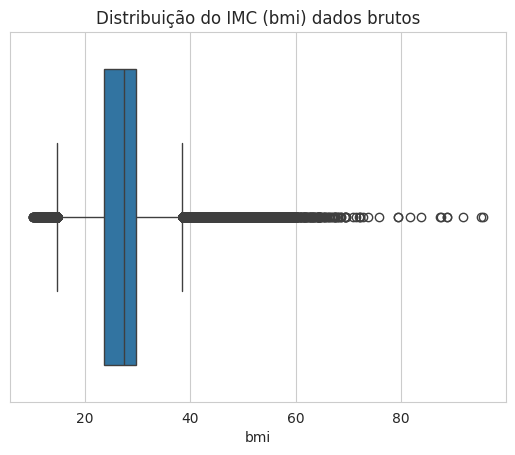

Limite Inferior (IQR): 14.705
Limite Superior (IQR): 38.504999999999995
Quantidade de outliers: 7086


In [ ]:
# @title EDA dados brutos

sns.boxplot(x=df['bmi'])
plt.title('Distribuição do IMC (bmi) dados brutos')
plt.show()


Q1 = df['bmi'].quantile(0.25)
Q3 = df['bmi'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(f"Limite Inferior (IQR): {limite_inferior}")
print(f"Limite Superior (IQR): {limite_superior}")
outliers = df[(df['bmi'] < limite_inferior) | (df['bmi'] > limite_superior)]
print(f"Quantidade de outliers: {len(outliers)}")

In [ ]:
#@title
limite_imc = 50

df['bmi_processed'] = df['bmi'].clip(upper=limite_imc)

ids_analisados = [87843, 76093, 69549, 96066, 4551]
print(df.loc[ids_analisados, ['age', 'bmi', 'bmi_processed', 'diabetes']])

        age    bmi  bmi_processed  diabetes
87843   7.0  95.69           50.0         0
76093  16.0  95.22           50.0         0
69549  38.0  91.82           50.0         0
96066  80.0  88.76           50.0         0
4551   45.0  88.72           50.0         1


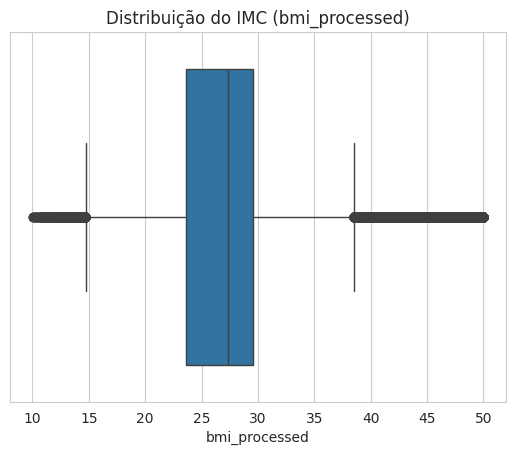

Limite Inferior (IQR): 14.705
Limite Superior (IQR): 38.504999999999995
Quantidade de outliers: 7086


In [ ]:
sns.boxplot(x=df['bmi_processed'])
plt.title('Distribuição do IMC (bmi_processed)')
plt.show()


Q1 = df['bmi'].quantile(0.25)
Q3 = df['bmi'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(f"Limite Inferior (IQR): {limite_inferior}")
print(f"Limite Superior (IQR): {limite_superior}")
outliers = df[(df['bmi'] < limite_inferior) | (df['bmi'] > limite_superior)]
print(f"Quantidade de outliers: {len(outliers)}")

### Distribuição de Variáveis

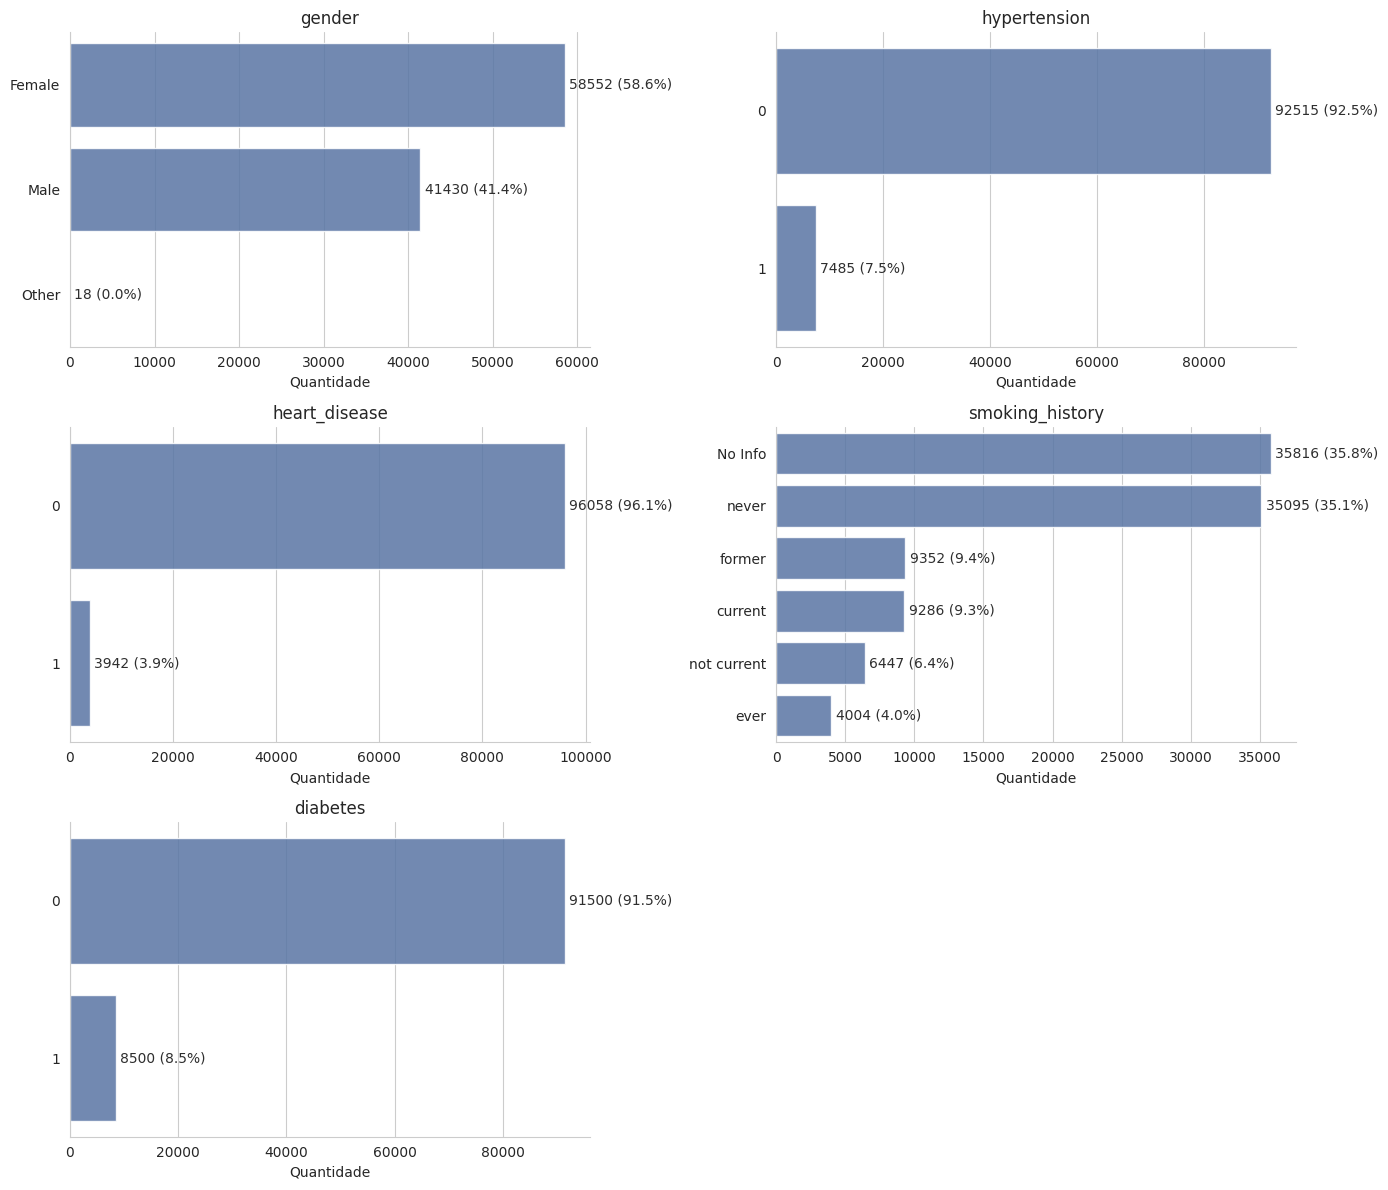

In [ ]:
# @title Variáveis qualitativas
variaveis_qualitativas = (
    df_dict
    .query("tipo == 'qualitativa'")
    .variavel
    .to_list()
)

n_vars = len(variaveis_qualitativas)
n_cols = 2
n_rows = -(-n_vars // n_cols)

fig, axes = plt.subplots(
    figsize=(14, 4 * n_rows),
    ncols=n_cols,
    nrows=n_rows
)

axes = axes.flatten()

for i, variavel in enumerate(variaveis_qualitativas):

    order = df[variavel].value_counts().index
    total = len(df)

    ax = sns.countplot(
        data=df,
        y=variavel,
        order=order,
        ax=axes[i],
        color="#4C72B0",
        alpha=0.85
    )

    for container in ax.containers:
        labels = [
            f"{int(v)} ({100*v/total:.1f}%)"
            for v in container.datavalues
        ]

        ax.bar_label(
            container,
            labels=labels,
            label_type="edge",
            padding=3,
            color="#2E2E2E",
            fontsize=10
        )

    ax.set_title(variavel, fontsize=12)
    ax.set_xlabel("Quantidade")
    ax.set_ylabel("")

    sns.despine(ax=ax, left=False)

for j in range(n_vars, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



---
- A maior parte dos participantes estao na categoria de saudaveis, e apenas 8500 tem diabetes

- A variavel smoking tem alguns dados ambiguos, sendo o never e o nao informado os que mais ocorrem no dataset

- A maior parte dos participantes é do sexo feminino


---




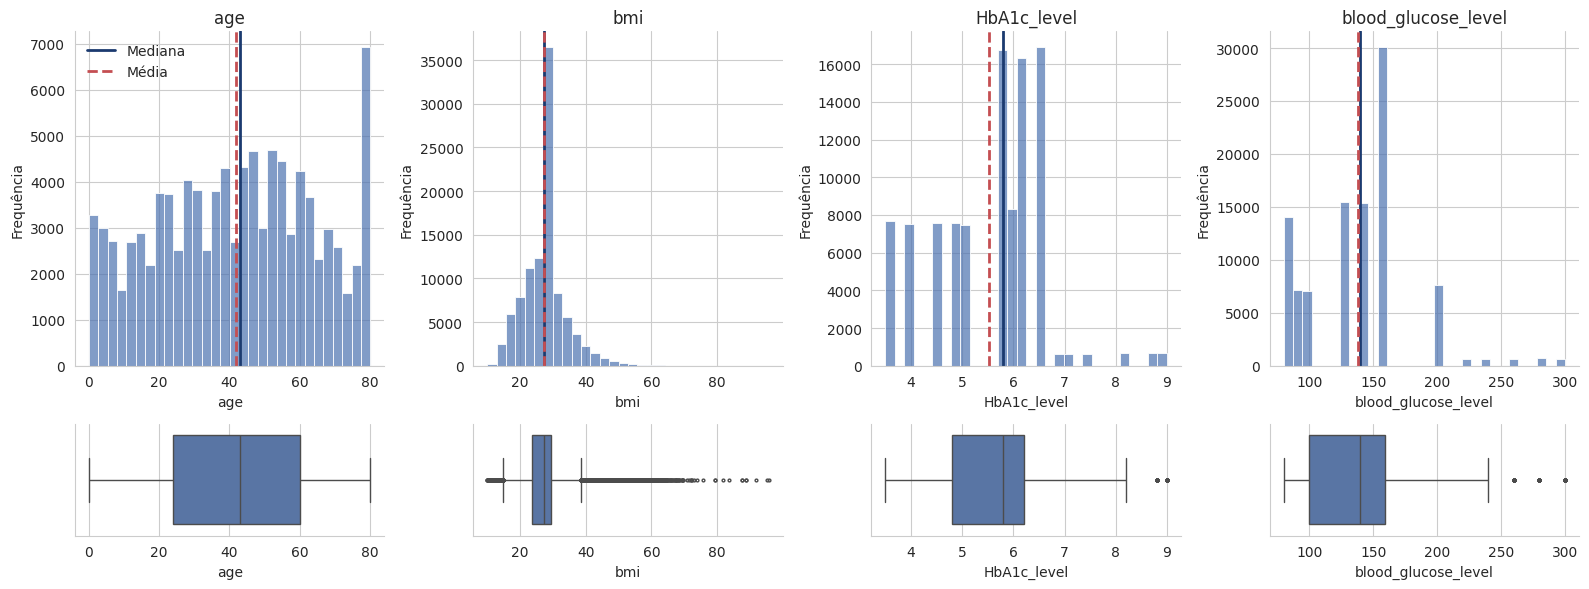

In [ ]:
# @title Variáveis quantitativas
variaveis_quantitativas = (
    df_dict
    .query("tipo == 'quantitativa'")
    .variavel
    .to_list()
)

fig, axes = plt.subplots(
    figsize=(4 * len(variaveis_quantitativas), 6),
    ncols=len(variaveis_quantitativas),
    nrows=2,
    gridspec_kw={"height_ratios": [3, 1]}
)

if len(variaveis_quantitativas) == 1:
    axes = axes.reshape(2, 1)

for i, variavel in enumerate(variaveis_quantitativas):

    ax = sns.histplot(
        data=df,
        x=variavel,
        bins=30,
        ax=axes[0, i],
        color="#4C72B0",
        alpha=0.7,
        edgecolor=None
    )

    ax.axvline(
        df[variavel].median(),
        color="#1B3A6F",
        linewidth=2,
        label="Mediana" if i == 0 else None
    )

    ax.axvline(
        df[variavel].mean(),
        color="#C44E52",
        linestyle="--",
        linewidth=2,
        label="Média" if i == 0 else None
    )

    ax.set_title(variavel)
    ax.set_ylabel("Frequência")

    if i == 0:
        ax.legend(frameon=False)

    sns.despine(ax=ax)

    sns.boxplot(
        data=df,
        x=variavel,
        ax=axes[1, i],
        color="#4C72B0",
        fliersize=2,
        linewidth=1
    )

    sns.despine(ax=axes[1, i])

plt.tight_layout()
plt.show()


A distribuição do IMC é unimodal e positivamente assimétrica, com a moda e a mediana situadas próximas a 27.32. Isso indica que a maior parte da amostra se encontra na faixa de sobrepeso, com uma cauda longa de outliers que se estende até o IMC de 95.
A idade apresenta uma distribuição aproximadamente simétrica, com média e mediana próximas aos 41-43 anos. Embora o dataset abranja desde recém-nascidos até idosos de 80 anos, a concentração central nessa faixa etária mostra que o estudo foca em uma população adulta madura.
Os níveis de HbA1c mostram uma forte concentração entre 5.7 e 6.6, o que coloca grande parte da amostra no limiar do pré-diabetes segundo os critérios clínicos.
A predominância de glicemia em 130-150 mg/dL diverge da GME (Glicose Média Estimada) calculada a partir da HbA1c (que seria ~111-125 mg/dL para uma glicada de 5.7 a 6.0).


---


# **Análise Bivariada**

---


#### *Investigar relações par a par entre variáveis quantitativas, qualitativas e mistas.*

## Informações básicas



## Relação entre Variáveis Quantitativas

In [ ]:
# @title Dados Estatistícos das variáveis quantitativas contínuas

vars_quant = [col for col in df.columns
  if df[col].dtype in ['int64', 'float64'] and df[col].nunique() >2
              and col != 'bmi_processed']

df_quant= df[vars_quant]

df_quant.describe()

,age,bmi,HbA1c_level,blood_glucose_level
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,27.320767,5.527507,138.058060
std,22.516840,6.636783,1.070672,40.708136
min,0.080000,10.010000,3.500000,80.000000
25%,24.000000,23.630000,4.800000,100.000000
50%,43.000000,27.320000,5.800000,140.000000
75%,60.000000,29.580000,6.200000,159.000000
max,80.000000,95.690000,9.000000,300.000000


###Gráficos de dispersão


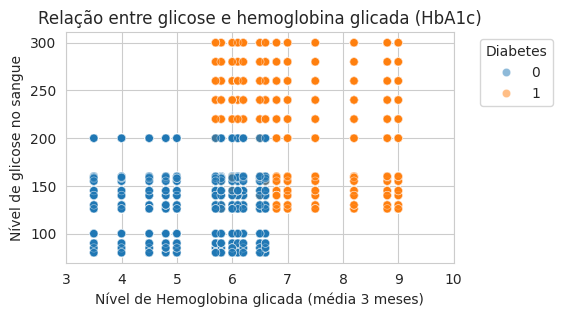

In [ ]:
#@title Comportamento PAR a PAR

display(Markdown("###Gráficos de dispersão\n"))

df1 = df[["HbA1c_level","blood_glucose_level", "bmi","diabetes"]]

fig = plt.figure(figsize=(5,3))
sns.set_style("whitegrid")

#definições do gráfico

xy = sns.scatterplot(df1, x="HbA1c_level", y="blood_glucose_level", hue= "diabetes",  palette = "tab10", alpha = 0.5 )

xy.set(
    title= "Relação entre glicose e hemoglobina glicada (HbA1c)",
    xlabel = "Nível de Hemoglobina glicada (média 3 meses)",
    ylabel = "Nível de glicose no sangue",
    xlim=(3,10)

)
plt.legend(title="Diabetes", bbox_to_anchor=(1.05, 1), loc='upper left')


#Exibindo o gráfico
plt.show()




> Pacientes classificados com diabetes apresentam uma grande concentração do lado superior direito, sugerindo uma correlação positiva entre as variáveis. Nota-se, que conforme o nível de hemoglobina glicada aumenta, a probabilidade de níveis de glicose também aumentam, o que é até esperado biologicamente. Contudo, a visualização também expõe algumas discrepâncias como por exemplo:nota-se uma parcela de participantes com níveis de glicose no sangue superiores a 200 mg/dl(possível diabetes), apesar de apresentarem HbA1c em níveis **normais** entre 3,5 a 6.


> Isso pode indicar outliers ou ruídos, possivelmente causados por situações como estresse, medições realizadas em período pós-prandial, jejum inadequado ou erro por contaminação. Com essa observação, percebe-se que a análise da glicose isolada pode levar a conclusões equivocadas sobre o diagnóstico final da diabetes.





###Gráficos de dispersão IMC X Nível de glicose no sangue


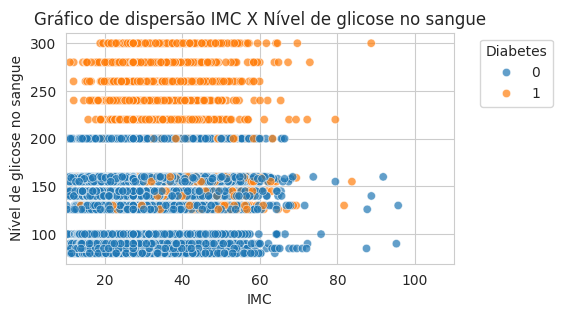

In [ ]:
display(Markdown("###Gráficos de dispersão IMC X Nível de glicose no sangue\n"))

fig = plt.figure(figsize=(5,3))
sns.set_style("whitegrid")

#definições do gráfico

ax = sns.scatterplot(df1, x ="bmi", y="blood_glucose_level", hue = "diabetes", palette = "tab10", alpha = 0.7 )

ax.set(title ="Gráfico de dispersão IMC X Nível de glicose no sangue",
       ylabel = "Nível de glicose no sangue",
       xlabel = "IMC",
       xlim=(10,110)
       #ylim=(60,310)
       )

plt.legend(title="Diabetes", bbox_to_anchor=(1.05,1), loc="upper left")

#Exibindo o gráfico
plt.show()




##### Observa-se uma correlação positiva fraca entre as variáveis bmi(IMC) e blood_glucose_level(Nível de glicose no sangue). O  gráfico mostra claramente que, acima de 200 mg/dL de glicose quase todos os pontos são laranjas (pacientes diabéticos), independente do IMC. Indicando que o IMC não é um fator determinante para diagnosticar a diabetes, sendo necessários outros indicadores, como por exemplo o HbA1c(Hemogloblina Glicada).



In [ ]:
#@title Correlação

vars_quant = [col for col in df.columns
  if df[col].dtype in ['int64', 'float64'] and df[col].nunique() >2
              and col != 'bmi_processed']

df_quant= df[vars_quant]

corr = df_quant.corr(numeric_only=True) #cálculo da matriz de correlação

corr.head()

,age,bmi,HbA1c_level,blood_glucose_level
age,1.000000,0.337396,0.101354,0.110672
bmi,0.337396,1.000000,0.082997,0.091261
HbA1c_level,0.101354,0.082997,1.000000,0.166733
blood_glucose_level,0.110672,0.091261,0.166733,1.000000


### Heatmap

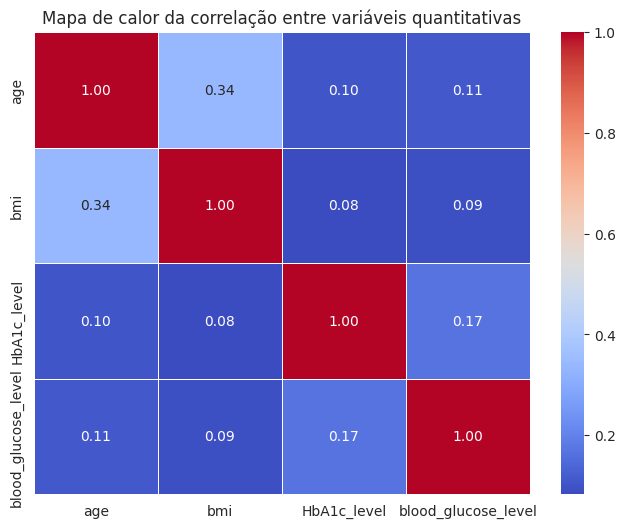

In [ ]:
display(Markdown("### Heatmap"))
# Continuação - Correlação

corr = df_quant.corr(method='pearson')

fig = plt.figure(figsize=(8,6))

sns.heatmap(corr,
            annot = True,
            fmt = ".2f",
            cmap="coolwarm",
            linewidths = 0.5
           )

plt.title('Mapa de calor da correlação entre variáveis quantitativas')
plt.show()



> O gráfico de correlação sugere que as variáveis quantitativas contínuas apresentam correlações positivas de baixa magnitude. A maior correlação observada na visualização ocorre entre idade (age) e IMC (bmi), com coeficiente de (r= 0,34), caracterizando uma correlação positiva fraca. Isso sugere que a medida que a idade do paciente aumenta, existe uma leve tendência de aumento do IMC também. No entanto, essa relação é limitada e por isso não é um fator determinante para o diagnóstico de diabetes, sendo necessária a consideração de outros indicadores clínicos para uma análise mais criteriosa.



> O coeficiente 0.17 representa a segunda correlação mais observada na análise, apresentando uma correlação positiva fraca entre HbA1c_level(Hemoglobina Glicada) e blood_glucose_level(glicose), que também pode ser explicado biologicamente, porém não configura fator determinante segundo os critérios estatísticos.








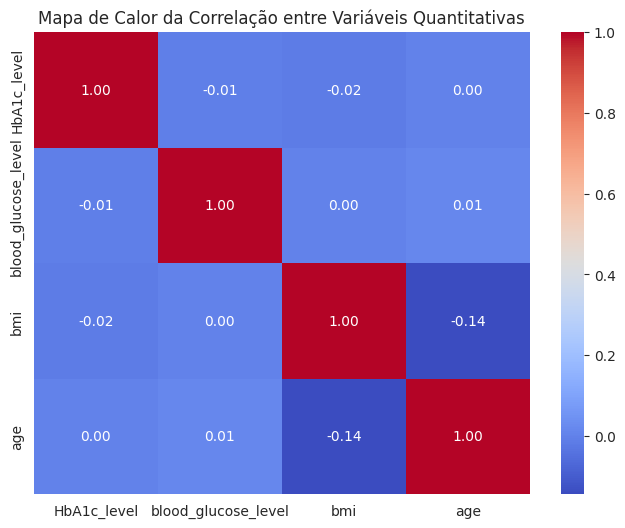

In [ ]:
#@title Correlação entre as variaveis quantitativas e a presença de diabetes
correlation_matrix_dt = df[df['diabetes'] == 1][['HbA1c_level', 'blood_glucose_level', 'bmi', 'age']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix_dt, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Calor da Correlação entre Variáveis Quantitativas')
plt.show()


---

- A correlação entre IMC e Idade inverteu o sinal e ficou negativa para diabéticos. Isso pode indicar que, neste grupo específico, os pacientes mais velhos talvez não sejam necessariamente os de maior IMC (ou pode haver um viés de sobrevivência/tratamento).

---

In [ ]:
df['gme'] = (df['HbA1c_level'] * 28.7) - 46.7
print(df[['HbA1c_level', 'gme']].head())

   HbA1c_level     gme
0          6.6  142.72
1          6.6  142.72
2          5.7  116.89
3          5.0   96.80
4          4.8   91.06


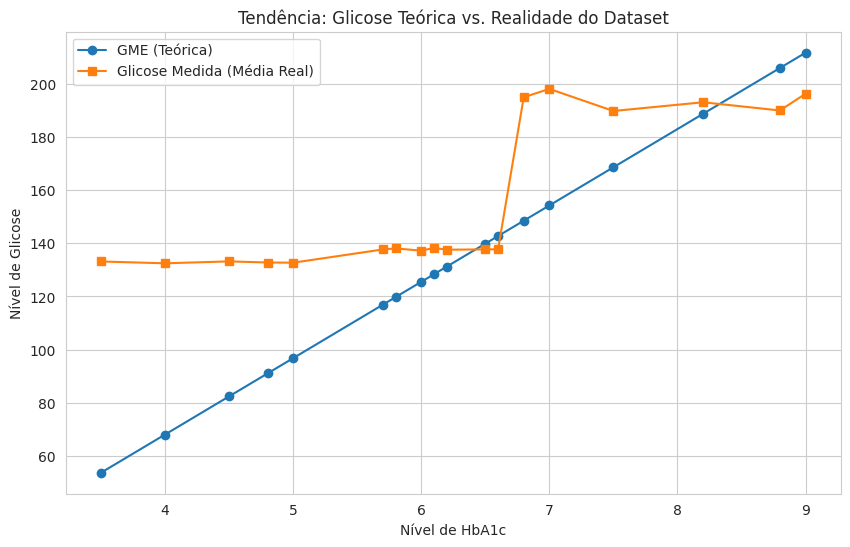

In [ ]:
# Agrupando pela HbA1c para ver a tendência média
df_grouped = df.groupby('HbA1c_level')[['blood_glucose_level', 'gme']].mean().reset_index()

plt.figure(figsize=(10, 6))
plt.plot(df_grouped['HbA1c_level'], df_grouped['gme'], label='GME (Teórica)', marker='o')
plt.plot(df_grouped['HbA1c_level'], df_grouped['blood_glucose_level'], label='Glicose Medida (Média Real)', marker='s')

plt.title('Tendência: Glicose Teórica vs. Realidade do Dataset')
plt.xlabel('Nível de HbA1c')
plt.ylabel('Nível de Glicose')
plt.legend()
plt.grid(True)
plt.show()


---

A análise visual (Gráfico de Tendência) revelou uma disparidade significativa entre a glicose medida e a Glicose Média Estimada (GME) teórica. A presença de pacientes não diabéticos com glicemia de 200 mg/dL e HbA1c normal (4.0 - 5.0) sugere erros pré-analíticos, como falha no jejum ou contaminação da amostra. Esses achados, somados aos IMCs biologicamente implausíveis identificados no Boxplot, fundamentam a necessidade de um pré-processamento rigoroso antes do treinamento de modelos de IA

---


## Relação entre variáveis qualitativas

In [ ]:
df_noinfo= df.query("smoking_history =='No Info'")
df_noinfo.describe()


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,bmi_processed,gme
count,35816.000000,35816.000000,35816.000000,35816.000000,35816.000000,35816.000000,35816.000000,35816.000000,35816.000000
mean,33.538037,0.033560,0.025771,25.343505,5.461607,135.244248,0.040596,25.314254,110.048108
std,24.955647,0.180097,0.158452,6.387415,1.021346,37.793658,0.197356,6.238829,29.312639
min,0.080000,0.000000,0.000000,10.010000,3.500000,80.000000,0.000000,10.010000,53.750000
25%,10.000000,0.000000,0.000000,20.710000,4.800000,100.000000,0.000000,20.710000,91.060000
50%,30.000000,0.000000,0.000000,27.320000,5.800000,140.000000,0.000000,27.320000,119.760000
75%,54.000000,0.000000,0.000000,27.320000,6.200000,158.000000,0.000000,27.320000,131.240000
max,80.000000,1.000000,1.000000,95.690000,9.000000,300.000000,1.000000,50.000000,211.600000


In [ ]:
# @title Contingência

def tabela_contigencia(df, var1, var2):

  # Análise de relacionamento entre duas variáveis categóricas

  print(f" Análise: {var1}VS {var2}")

  # tabela de contigência

  contingency=pd.crosstab(df[var1], df[var2])
  print("Tabela de contigência: frequência absoluta")
  print(contingency)

  #Tabela percentual( é por linha)

  perc_tabela = pd.crosstab(df[var1], df[var2], normalize="index") * 100
  print("\n Distribuição percentual por linha  \n")
  print(perc_tabela.round(2))

  # Teste Qui-quadrado

  chi2,p_value, dof, expected = st.chi2_contingency(contingency)
  print(f"\n chi: {chi2:.2f}")
  print(f"p_valor: {p_value:.2f}")
  print(f"graus de liberdade:", {dof})
  print("Há associação significativa?", "SIM" if p_value < 0.05 else "Não")


  n = contingency.sum().sum()
  cramers_v = np.sqrt(chi2/ (n*(min(contingency.shape)-1)))
  print(f"Cramér's V = {cramers_v:.3f} \n \n")

  fig, axes = plt.subplots(1,2,figsize=(10,6))


  sns.heatmap(contingency, annot=True, fmt=".2f", cmap ="Blues", ax=axes[0])
  axes[0].set_title("Tabela de contingência")

  perc_tabela.plot(kind="bar",stacked=True, ax=axes[1])
  axes[1].set_ylabel("Percentual %")
  axes[1].set_title("Distribuição percentual por grupo")
  axes[1].legend(title=var2, bbox_to_anchor=(1.05,1))

  plt.tight_layout()
  plt.show()



 Análise: smoking_historyVS diabetes
Tabela de contigência: frequência absoluta
diabetes             0     1
smoking_history             
No Info          34362  1454
current           8338   948
ever              3532   472
former            7762  1590
never            31749  3346
not current       5757   690

 Distribuição percentual por linha  

diabetes             0      1
smoking_history              
No Info          95.94   4.06
current          89.79  10.21
ever             88.21  11.79
former           83.00  17.00
never            90.47   9.53
not current      89.30  10.70

 chi: 1956.09
p_valor: 0.00
graus de liberdade: {5}
Há associação significativa? SIM
Cramér's V = 0.140 
 



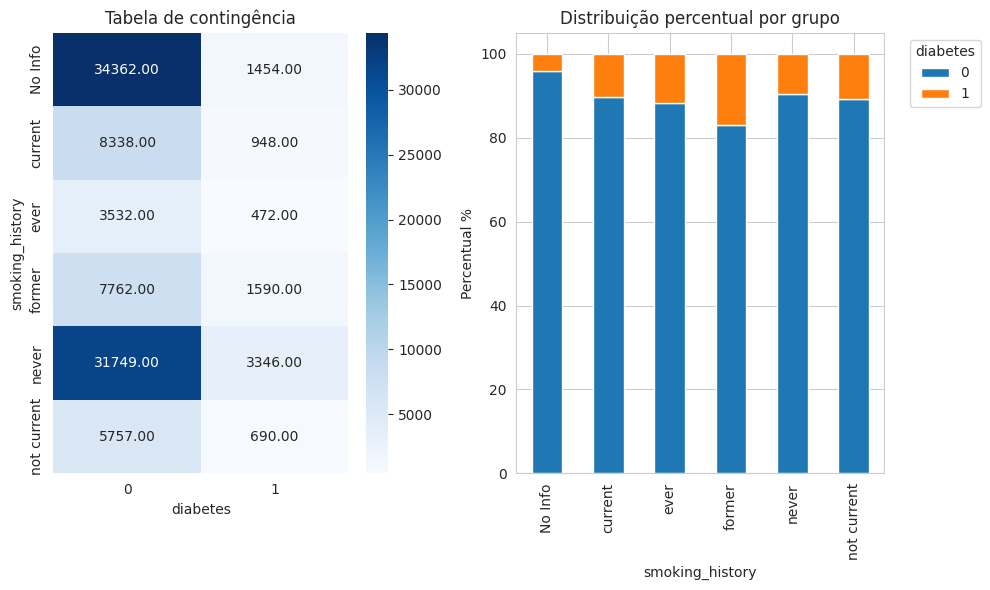

In [ ]:
tabela_contigencia(df,"smoking_history", "diabetes")


> O gráfico e dados estatísticos demonstram que embora a associação exista, sua força é considerada fraca, sinalizando que o tabagismo é um fator contribuinte, mas não o único determinante da doença. Além disso, a distribuição percentual destaca que o grupo de ex-fumantes(former) apresenta maior prevalência de diabetes(17%) de cados positivos, superior aos casos de pacientes que nunca fumaram/never (9,53%). Observa-se que a categoria "No info"(sem informação) registrou a menor taxa de diabetes (4,06%). Sendo que 25% do grupo é composto por crianças de até 10 anos. O histórico de fumo não explica sozinho a diabete.



## Relação entre variáveis quantitativas e qualitativas

In [ ]:
# @title Distribuição relativa

### A HbA1 diferente entre diabéticos e não diabéticos?

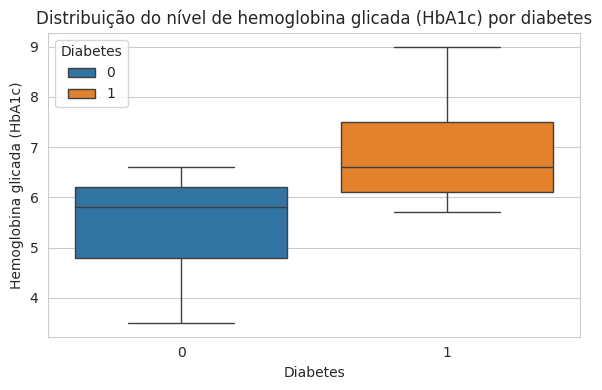

In [ ]:
display(Markdown("### A HbA1 diferente entre diabéticos e não diabéticos?"))

fig = plt.figure(figsize=(6,4))
ax1= sns.boxplot(data=df, x="diabetes", y="HbA1c_level", hue="diabetes")

ax1.set(title=
        "Distribuição do nível de hemoglobina glicada (HbA1c) por diabetes",
        xlabel = "Diabetes",
        ylabel= "Hemoglobina glicada (HbA1c)"
        )

plt.legend(title="Diabetes", loc="upper left")
plt.tight_layout()
plt.show()




> Observa-se no gráfico acima uma separação visual bem clara entre as duas distribuições, enquanto os indivíduos não diabéticos possuem uma mediana equivalente a 5.8, pacientes diabéticos apresentam uma mediana mais elevada, aproximadamente 6.5. O limite superior dos indivíduos não diabéticos termina próximo da mediana dos pacientes diabéticos. Sugerindo a maior concentração de valores acima de 6.5 da HbA1c pertencem aos casos positivos da doença.



###Pessoas com hipertensão apresentam níveis de glicose diferentes das que não têm hipertensão?

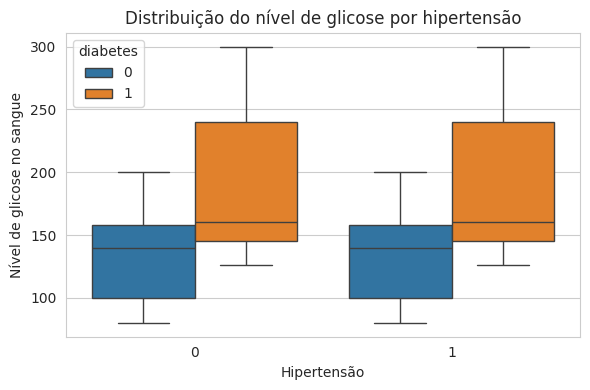

In [ ]:
display(Markdown("###Pessoas com hipertensão apresentam níveis de glicose diferentes das que não têm hipertensão?"))
fig = plt.figure(figsize=(6,4))

ax2 = sns.boxplot(
    data=df,
    x="hypertension",
    y="blood_glucose_level", hue="diabetes"
)

ax2.set(
    title="Distribuição do nível de glicose por hipertensão",
    xlabel="Hipertensão",
    ylabel="Nível de glicose no sangue"
)

plt.tight_layout()
plt.show()



> A hipertensão não atua como fator determinante para elevação dos níveis de glicose no sangue, pois a presença dessa comorbidade não altera significamente a classificação, observa-se que a distribuição dos grupos apresentam medianas e amplitudes visualmente idênticas. Ela não sugere uma relação bivariada com o aumento "imediato" da glicose no sangue. O gráfico sugere que o comportamento da glicemia é governado pelo diagnóstico da diabetes.



### O nível de glicose muda entre fumantes e não fumantes, considerando a diabetes?

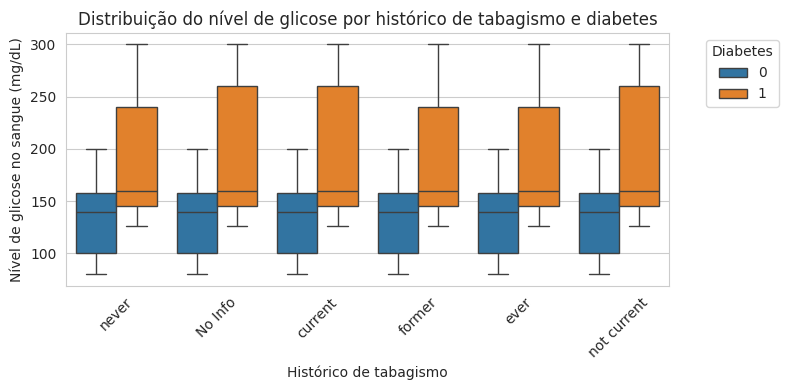

In [ ]:
display(Markdown("### O nível de glicose muda entre fumantes e não fumantes, considerando a diabetes?"))
ig =plt.figure(figsize=(8,4))

ax2= sns.boxplot(
    data=df,
    x="smoking_history",
    y="blood_glucose_level",
    hue="diabetes"

)


plt.title("Distribuição do nível de glicose por histórico de tabagismo e diabetes")
plt.xlabel("Histórico de tabagismo")
plt.ylabel("Nível de glicose no sangue (mg/dL)")
plt.legend(title="Diabetes", bbox_to_anchor=(1.05,1), loc="upper left")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




> Observa-se que o nível de glicose não apresenta mudança entre fumantes e não fumantes. O histórico de tabagismo também não configura resposta para o diagnóstico da diabetes. Conforme observado, em indivíduos não diabéticos, a mediana permanece estática indepentende do histórico de tabagismo dos indivíduos do conjunto de dados. O gráfico indica que o impacto do tabagismo no nível de glicose é desprezível comparado ao impacto do diagnóstico de diabetes, que é o verdadeiro determinante para a elevação e variabilidade do indicador(Nível de glicose). Observação: identificação da categoria do histórico de tabagismo ("No info/sem informação") na base de dados.



---

# **Análise multivariada**

---


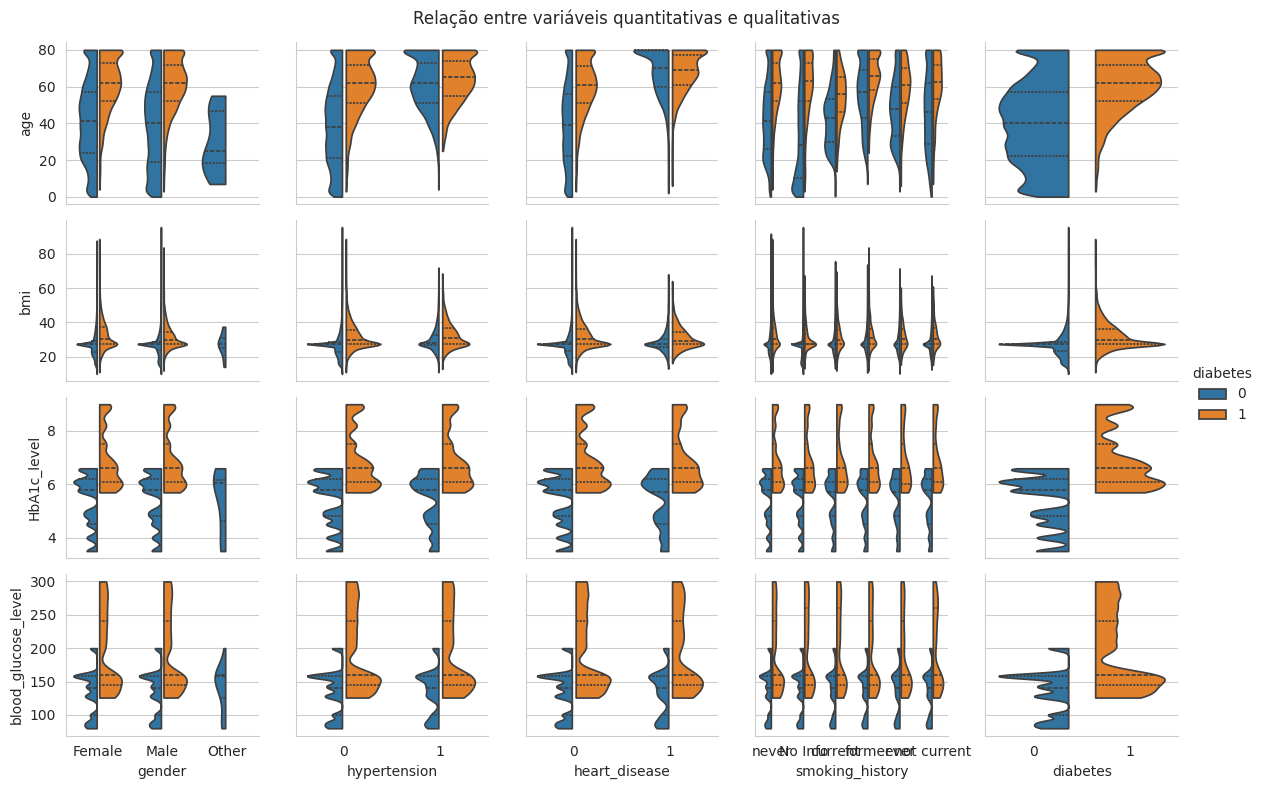

In [ ]:
# @title Distribuição conjunta
g = sns.PairGrid(
    df, y_vars=variaveis_quantitativas, x_vars=variaveis_qualitativas, hue='diabetes',
    height=3
)
g.fig.set_size_inches(12, 8)
g.map(sns.violinplot, split=True, inner="quart", gap=.1, cut=0, legend=True),

plt.suptitle('Relação entre variáveis quantitativas e qualitativas')
plt.tight_layout()
g.add_legend()



---

Utilizando a distribuição conjunta por meio de gráficos de violino, observou-se que pacientes diabéticos (laranja) apresentam uma densidade significativamente maior em níveis elevados de HbA1c e glicose. Contudo, a presença de 'caudas' longas e finas em pacientes não diabéticos (azul) no IMC e na glicemia reforça a hipótese de inconsistências pontuais nos dados, que não seguem a tendência central da amostra

---



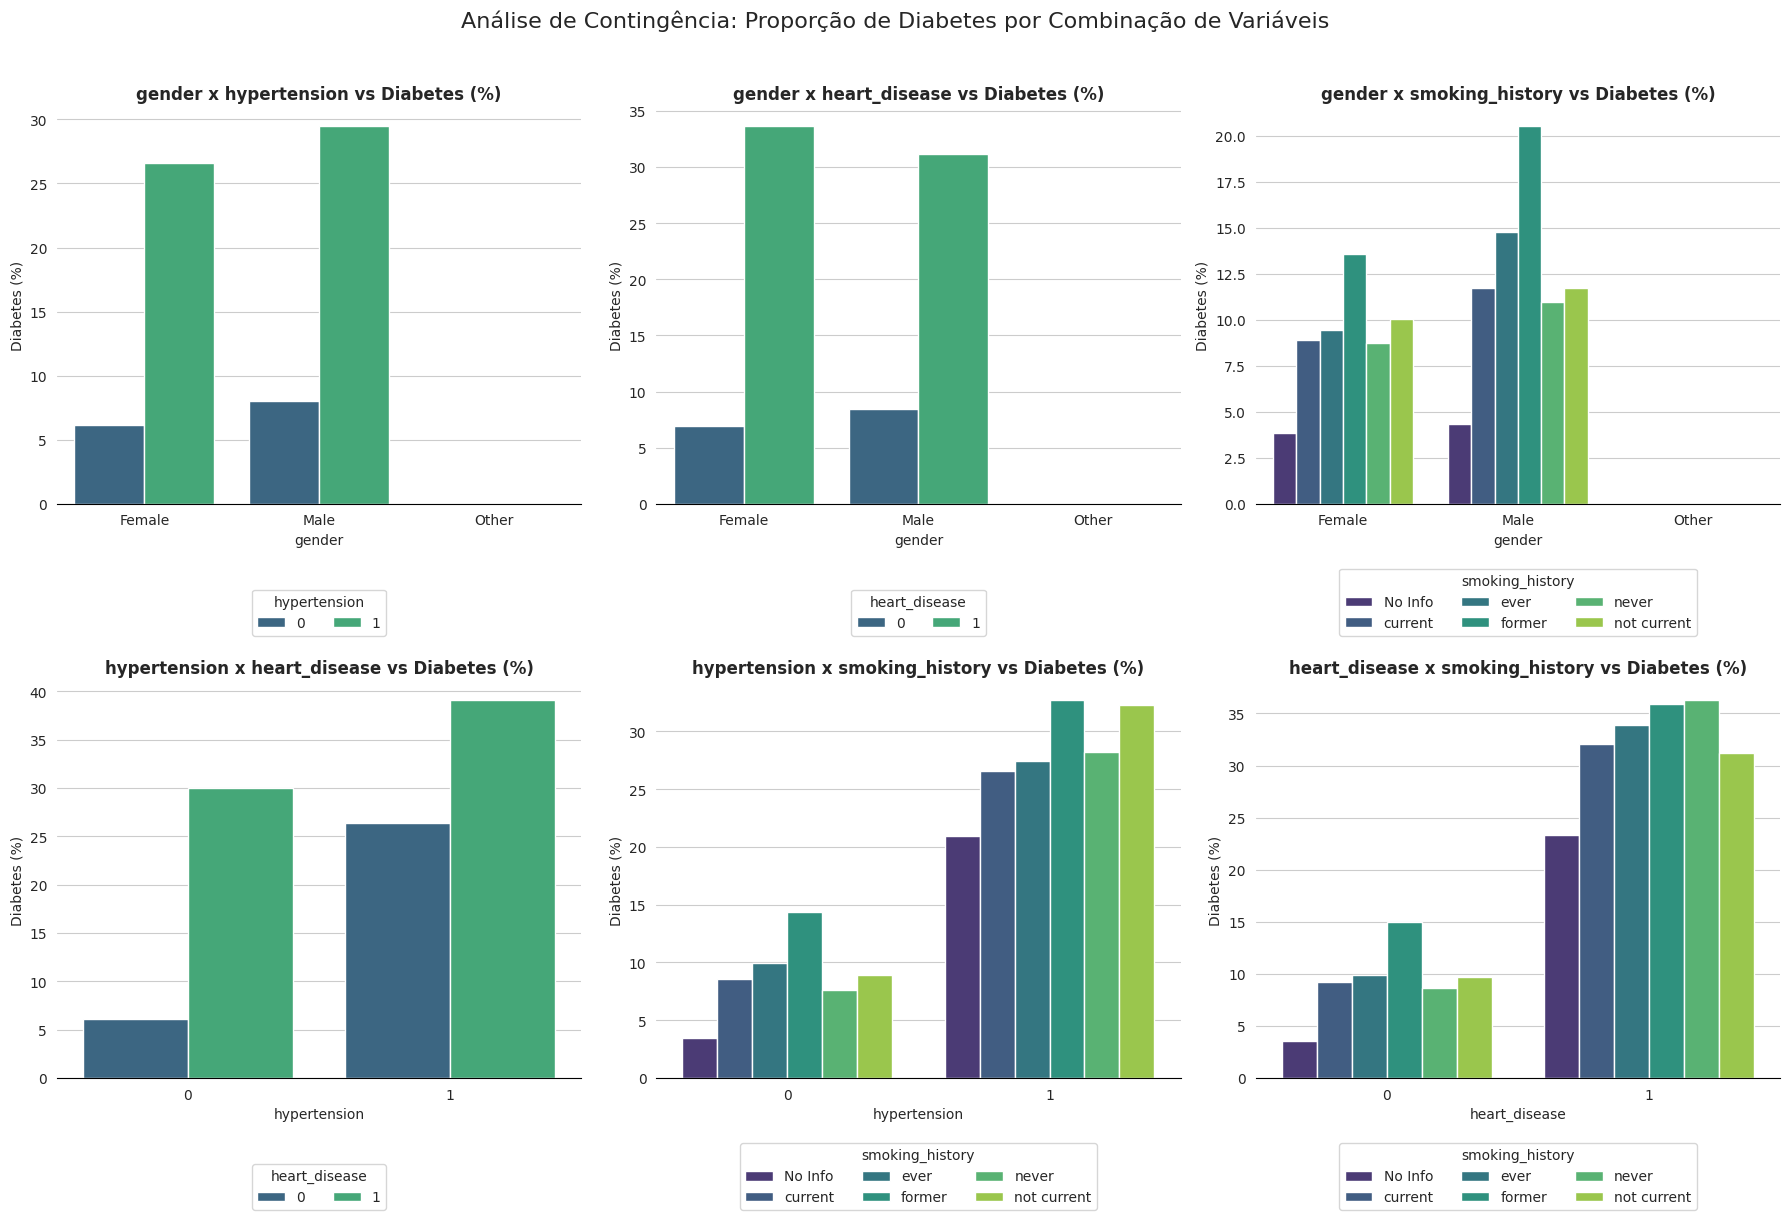

In [ ]:
# @title Contingência
sns.set_style('whitegrid')


variaveis_qualitativas = ['gender', 'hypertension', 'heart_disease', 'smoking_history']
alvo = 'diabetes'


combinacoes = list(itertools.combinations(variaveis_qualitativas, 2))


fig, axes = plt.subplots(figsize=(18, 12), ncols=3, nrows=2)
axes = axes.flatten()

for i, (var_1, var_2) in enumerate(combinacoes):
    if i >= len(axes): break



    df_plot = df.groupby([var_1, var_2])[alvo].mean().reset_index()
    df_plot[alvo] = df_plot[alvo] * 100  #transforma em procentagem


    ax = sns.barplot(
        data=df_plot, x=var_1, y=alvo, hue=var_2,
        palette='viridis', ax=axes[i], capsize=.1
    )


    ax.set_title(f"{var_1} x {var_2} vs Diabetes (%)", fontsize=12, fontweight='bold')
    ax.set_ylabel("Diabetes (%)")
    ax.set_xlabel(var_1)

    for side in ["left", "top", "right"]:
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color("black")


    sns.move_legend(
        ax, "lower center",
        bbox_to_anchor=(.5, -0.35), ncol=3, title=var_2, frameon=True
    )

plt.suptitle("Análise de Contingência: Proporção de Diabetes por Combinação de Variáveis", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()



---


Olhando o gráfico hypertension x heart_disease, observa-se que quem tem as duas condições chega a quase 40% de chance de ser diabético. É o maior risco observado em todo o estudo qualitativo.

No gráfico hypertension x smoking_history, para quem já é hipertenso, o histórico de fumo (especialmente ever, former e not current) mantém a incidência de diabetes consistentemente acima dos 30%.

No gráfico heart_disease x smoking_history, nota-se que pacientes com doença cardíaca que são ex-fumantes (former) ou que pararam de fumar recentemente (not current) têm os índices mais altos, sugerindo que o risco metabólico persiste mesmo após a interrupção do hábito.

Embora a base de dados seja equilibrada, o gênero feminino apresenta a maior concentração de pacientes com doenças cardíacas e diabetes combinados, enquanto o gênero masculino lidera na relação entre hipertensão e diabetes.

Persistência do Risco no Tabagismo: Homens ex-fumantes (former) possuem a maior porcentagem de diabéticos em comparação a todas as outras categorias de fumo, sugerindo que o risco metabólico permanece elevado mesmo após a cessação do hábito.

---



<Figure size 800x600 with 0 Axes>

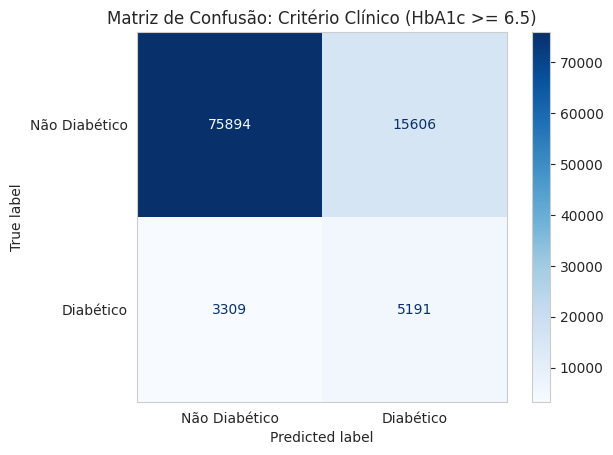

In [ ]:
#@title Matriz de Confusão

df['predicao_simples'] = (df['HbA1c_level'] >= 6.5).astype(int)

cm = confusion_matrix(df['diabetes'], df['predicao_simples'])

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Não Diabético', 'Diabético'])
disp.plot(cmap='Blues', values_format='d')

plt.title('Matriz de Confusão: Critério Clínico (HbA1c >= 6.5)')
plt.grid(False)
plt.show()

A matriz de confusão demonstra que, embora o nível de HbA1c seja um preditor isolado poderoso, ele gera um número considerável de falsos positivos (15.606). Isso reforça a necessidade de um modelo de Machine Learning multivariado (usando IMC, idade e histórico de fumo em conjunto) para refinar a classificação e reduzir esses erros, proporcionando um diagnóstico mais preciso do que um critério clínico único

PC1: 36.59%
PC2: 26.04%
PC3: 20.83%
PC4: 16.55%


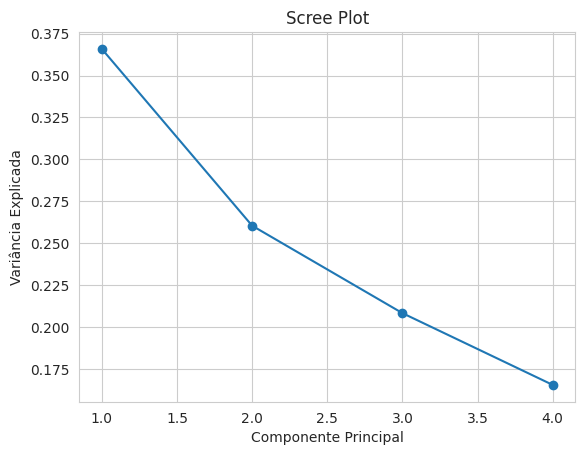

In [ ]:
#@title PCA - Componentes das variáveis continuas


variaveis_pca = (
    df_dict
    .query("tipo == 'quantitativa'")
    .variavel
    .to_list()
)

X = df[variaveis_pca]
X_scaled = StandardScaler().fit_transform(X)
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
explained_variance = pca.explained_variance_ratio_

for i, v in enumerate(explained_variance):
    print(f"PC{i+1}: {v:.2%}")

plt.plot(
    range(1, len(explained_variance) + 1),
    explained_variance,
    marker="o"
)
plt.xlabel("Componente Principal")
plt.ylabel("Variância Explicada")
plt.title("Scree Plot")
plt.show()


>O scree plot indica que a variância dos dados é gradualmente distribuída entre as componentes principais, sem um cotovelo bem definido, sendo as duas primeiras componentes suficientes para visualização exploratória.

In [ ]:
var_exp = pca.explained_variance_ratio_

pc1_var = var_exp[0] * 100
pc2_var = var_exp[1] * 100

loadings = pd.DataFrame(
    pca.components_,
    columns=variaveis_pca,
    index=[f"PC{i+1}" for i in range(len(variaveis_pca))]
)

loadings.iloc[:2]


,age,bmi,HbA1c_level,blood_glucose_level
PC1,0.601364,0.583144,0.377844,0.394384
PC2,-0.356449,-0.415342,0.607774,0.575367


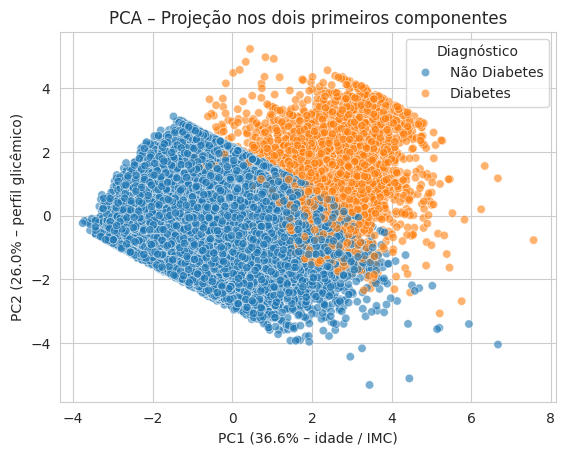

In [ ]:
df_pca = pd.DataFrame(
    X_pca[:, :2],
    columns=["PC1", "PC2"]
)
df_pca["diabetes"] = df["diabetes"].values

sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="diabetes",
    alpha=0.6
)

plt.xlabel(f"PC1 ({pc1_var:.1f}% – idade / IMC)")
plt.ylabel(f"PC2 ({pc2_var:.1f}% – perfil glicêmico)")
plt.title("PCA – Projeção nos dois primeiros componentes")

ax = plt.gca()
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles=handles,
    labels=["Não Diabetes", "Diabetes"],
    title="Diagnóstico"
)

plt.show()

>A projeção nos dois primeiros componentes principais revela uma tendência de separação entre os indivíduos com e sem diabetes no espaço reduzido. Observa-se que os indivíduos diagnosticados com diabetes concentram-se majoritariamente em regiões associadas a valores mais elevados das componentes principais, enquanto os não diabéticos ocupam predominantemente a região oposta. Embora exista sobreposição entre os grupos, a distribuição sugere uma estrutura multivariada consistente com diferenças nos perfis antropométricos e glicêmicos.

---

# **Sumário de insights e hipóteses**

---


- **Perfil Demográfico e Comorbidades (Variáveis Qualitativas)**
    - Perfil clínico dominante: apenas 8,5% da amostra possui diabetes, indicando que os dados são desbalanceados. Os pacientes diabéticos apresentam uma concentração clara em níveis elevados de HbA1c (mediana: 6,5) e glicose (picos de 300 mg/dL).
    - Hipertensão e Doenças Cardíacas: Existe uma correlação visual clara onde a presença dessas condições eleva drasticamente a proporção de pacientes diabéticos no dataset.
    - Histórico de Fumo: Ex-fumantes (former) apresentam a maior taxa proporcional de diabetes (~17%), seguidos por fumantes atuais, superando significativamente o grupo que nunca fumou.
    - Gênero: A distribuição da doença é equilibrada entre homens e mulheres, sugerindo que esta variável, isoladamente, pode ter menor peso preditivo que os fatores metabólicos.

- **Análise de Indicadores Clínicos (Variáveis Quantitativas)**
    - HbA1c como Preditor Ouro: O nível de hemoglobina glicada demonstrou ser o indicador mais confiável. A Matriz de Confusão revela que o critério clínico (HbA1c <= 6.5) acerta a grande maioria dos diagnósticos.
    - Glicemia de Jejum e Inconsistências: Identificamos uma anomalia onde muitos pacientes não diabéticos possuem glicose de 200 mg/dL com HbA1c normal. Isso levanta a hipótese de erros pré-analíticos, como falha no jejum ou contaminação da amostra no momento da coleta.
    - Desvio da Média (GME): A média da glicose medida no dataset desvia da Glicose Média Estimada teórica em níveis baixos de HbA1c, indicando possíveis ruídos sistemáticos na coleta de dados de pacientes saudáveis.
    - Correlações: As correlações entre variáveis contínuas são positivas, mas de baixa magnitude/correlação fraca. A maior delas ocorre entre idade e IMC (r = 0,34). A correlação entre HbA1c e glicose é de apenas 0,17, o que reforça que a glicose isolada é uma medida instável para análise.

- **Análise de Risco Acumulado (Insights Multivariados)**
    - Sinergia de Comorbidades: O cruzamento entre hipertensão e doenças cardíacas revela o maior índice de prevalência de diabetes em todo o dataset, atingindo aproximadamente 40% de incidência nos pacientes que apresentam ambas as condições simultaneamente.

    - Interações de Gênero: Embora a base de dados seja equilibrada, o gênero feminino apresenta a maior concentração de pacientes com doenças cardíacas e diabetes combinados, enquanto o gênero masculino lidera na relação entre hipertensão e diabetes.

    - Persistência do Risco no Tabagismo: Homens ex-fumantes (former) possuem a maior porcentagem de diabéticos em comparação a todas as outras categorias de fumo, sugerindo que o risco metabólico permanece elevado mesmo após a cessação do hábito.

    - Fator Multiplicador: Para pacientes já hipertensos, o histórico de fumo (especialmente nas categorias former e not current) mantém a incidência de diabetes consistentemente acima de 30%, reforçando que essas variáveis qualitativas atuam como multiplicadores de risco significativos para o modelo.

- **Outliers e Integridade dos Dados**
    - Anomalias de IMC: Foram detectados valores de IMC biologicamente implausíveis, como uma criança de 7 anos com IMC de 95.69. A ausência de doenças cardíacas nesses casos extremos reforça a teoria de erro de digitação.
    - Fragilidade Biológica: O IMC de 88 em idosos de 80 anos é improvável sem comorbidades severas, justificando a decisão técnica de realizar o capping para estabilizar o futuro modelo de IA.
    - A categoria "No Info" em smoking_history (35,8% da amostra) atua como um "dado faltante" que esconde um padrão: 25% desse grupo são crianças de até 10 anos, o que justifica a ausência de histórico de fumo.

- **Hipóteses para Modelagem**
    - Hipótese 1: O modelo terá alta performance focada em HbA1c e Glicemia, mas a limpeza do IMC via capping é vital para evitar que pesos matemáticos irreais distorçam as previsões.
    - Hipótese 2: Devido ao desbalanceamento de classes (muito mais não-diabéticos), será necessário aplicar técnicas de balanceamento para que o modelo não ignore a classe minoritária.
---
